# 🤖 Notebook 03: Baseline Model (TF-IDF + Logistic Regression)

**Project Title:** Email Intent Classification with Attention-Based Sequence Models and Priority Prediction  
**Phase Covered:** Phase 4 (Traditional Baseline Model)

---

### 🎯 Objectives:
1. Load cleaned email datasets (`train_emails.csv`, `val_emails.csv`, `test_emails.csv`).
2. Load pre-trained TF-IDF vectorizer (`models/tfidf_vectorizer.pkl`).
3. Train `LogisticRegression(max_iter=1000, random_state=42)` on TF-IDF features.
4. Evaluate baseline model performance on unseen test data.
5. Generate classification report, metrics summary, and confusion matrix visualization.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support, confusion_matrix
import joblib

sns.set_theme(style="whitegrid")
os.makedirs("../results/metrics", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)
os.makedirs("../models", exist_ok=True)


## 1. Load Processed Datasets & Vectorizer

In [2]:
train_df = pd.read_csv("../data/processed/train_emails.csv")
val_df = pd.read_csv("../data/processed/val_emails.csv")
test_df = pd.read_csv("../data/processed/test_emails.csv")

vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

X_train = vectorizer.transform(train_df['clean_email_text'])
X_val = vectorizer.transform(val_df['clean_email_text'])
X_test = vectorizer.transform(test_df['clean_email_text'])

y_train = train_df['intent']
y_val = val_df['intent']
y_test = test_df['intent']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")


X_train shape: (1773, 3592)
X_test shape:  (380, 3592)


## 2. Train Logistic Regression Classifier

In [3]:
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)
print("Model training complete.")


Model training complete.

## 3. Model Evaluation on Test Data

In [4]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')

print(f"Test Accuracy:           {acc:.4f}")
print(f"Weighted Precision: {prec_w:.4f}")
print(f"Weighted Recall:    {rec_w:.4f}")
print(f"Weighted F1-Score:  {f1_w:.4f}")
print(f"Macro F1-Score:     {f1_m:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy:           0.9000
Weighted Precision: 0.9017
Weighted Recall:    0.9000
Weighted F1-Score:  0.8987
Macro F1-Score:     0.9090

Classification Report:
                            precision    recall  f1-score   support

              availability       0.96      0.96      0.96        24
                complaints       0.79      0.92      0.85        24
    credit_and_collections       1.00      0.82      0.90        22
            delivery_issue       0.87      0.83      0.85        24
           invoice_request       0.88      1.00      0.93        21
          multiple_intents       0.78      0.71      0.74        41
order_modification_request       0.83      0.91      0.87        22
              order_status       1.00      0.95      0.98        21
              out_of_scope       0.90      1.00      0.95        19
                   pricing       0.96      1.00      0.98        22
  pricing_and_availability       0.95      1.00      0.98        21
              produ

## 4. Confusion Matrix Visualization

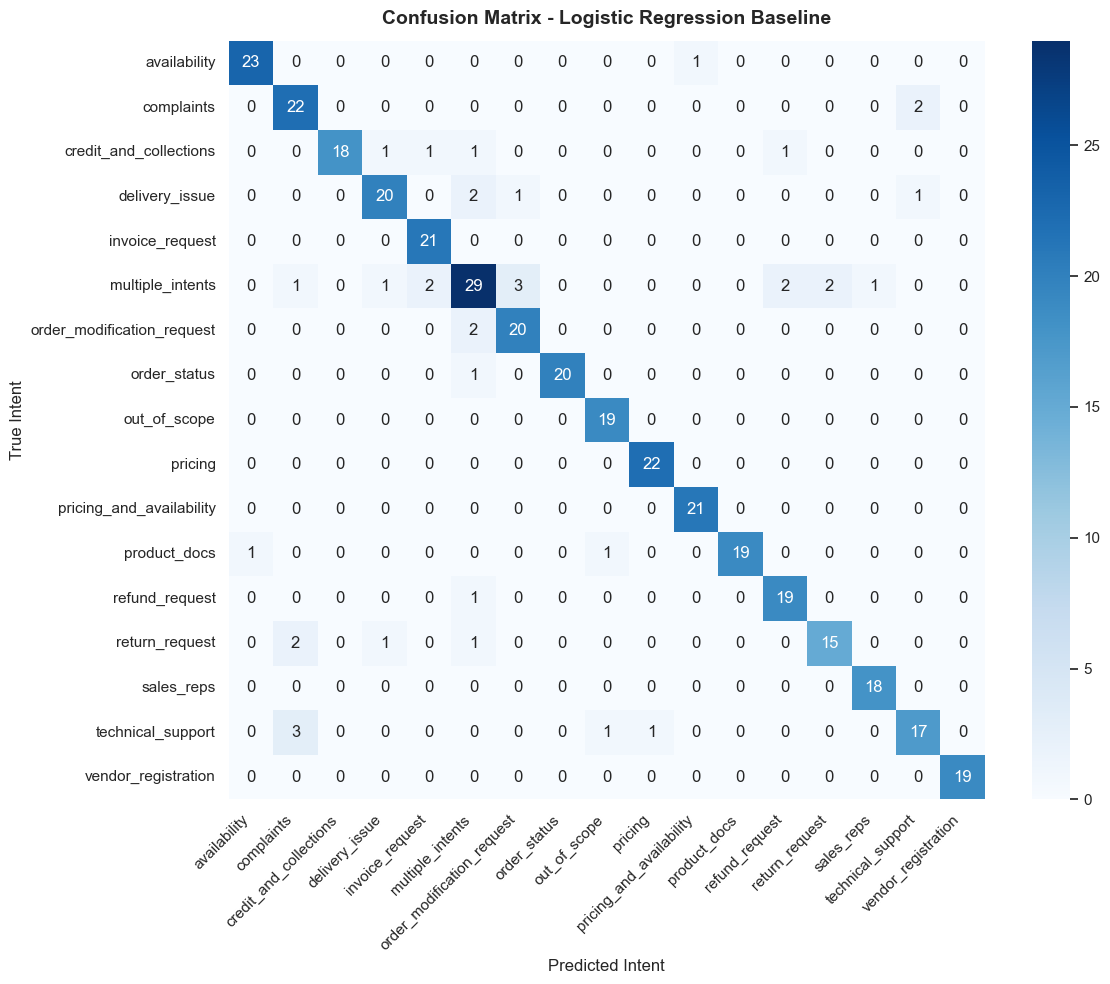

Artifacts saved successfully.


In [5]:
labels = sorted(list(y_test.unique()))
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Logistic Regression Baseline", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Predicted Intent")
plt.ylabel("True Intent")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/figures/logistic_regression_confusion_matrix.png", dpi=300)
plt.show()

# Save Model & Metrics
joblib.dump(clf, "../models/logistic_regression_model.pkl")

metrics_df = pd.DataFrame([{
    'Model': 'Logistic Regression',
    'Architecture': 'TF-IDF + Logistic Regression',
    'Accuracy': acc,
    'Precision': prec_w,
    'Recall': rec_w,
    'F1_Score': f1_w,
    'Macro_Precision': prec_m,
    'Macro_Recall': rec_m,
    'Macro_F1_Score': f1_m
}])
metrics_df.to_csv("../results/metrics/logistic_regression_metrics.csv", index=False)
print("Artifacts saved successfully.")
